# Support Vector Machine Model (SVM) — Fashion-MNIST Classification

## Pipeline

### **1. Data Processing & Split Strategy**
* **Data Loading:** Importing the Fashion-MNIST dataset (70,000 samples).
* **Splitting:** Implementing a stratified split strategy to ensure balanced class distributions across Training, Validation, and Test sets.

### **2. Custom Preprocessing (StandardScaler & PCA)**
* **Scaling:** Applying `StandardScaler` to achieve zero mean and unit variance, which is critical for RBF kernel convergence.
* **Dimensionality Reduction:** Utilizing **PCA** to retain **95% of cumulative variance**, effectively filtering noise and reducing the feature space from 784 to a lower-dimensional manifold.

### **3. Implementation Sanity Check**
* **GPU Readiness:** Verifying `cuML` compatibility and hardware acceleration.
* **Baseline Verification:** Testing the initial model configuration to ensure the pipeline architecture is functionally sound before optimization.

### **4. Hyperparameter Optimization (Optuna)**
* **Bayesian Tuning:** Leveraging **Optuna** to automate the search for optimal $C$ and $\gamma$ hyperparameters.
* **Justification:** Analyzing parameter influence through **fANOVA importance plots** to justify the final model configuration.

### **5. Statistical Stability & Final Evaluation**
* **Robustness Check:** Executing a **5-seed stability test** to report performance as Mean $\pm$ Standard Deviation ($\mu \pm \sigma$).
* **Unbiased Reporting:** Evaluating the final optimized model on the **10,000-sample hold-out test set** and performing qualitative error analysis.

### **6. Ablation Study (Component Impact Analysis)**
* **Component Isolation:** Systematically removing key preprocessing and optimization steps (e.g., PCA dimensionality reduction, feature scaling, and Optuna tuning) to establish baseline configurations.

* **Trade-off Justification:** Quantifying the direct impact of each architectural choice on both predictive performance (Macro-F1, Accuracy) and computational efficiency (Training Time) to scientifically validate the final proposed pipeline.

## 0. Import Library

In [19]:
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Machine Learning Models
from sklearn.dummy import DummyClassifier
from cuml.svm import SVC 

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


# Hyperparameter Tuning
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.importance import FanovaImportanceEvaluator 

import matplotlib.pyplot as plt
from optuna.visualization import matplotlib as optuna_plt
import seaborn as sns

import time

RANDOM_SEED = 42
SEEDS = [42, 5435, 123, 2026, 23]

%matplotlib inline
sns.set_theme(style="whitegrid")


import warnings
warnings.filterwarnings('ignore')

print("All necessary libraries have been successfully imported!")

All necessary libraries have been successfully imported!


## 1. Data Processing & Split Strategy
This stage establishes the data foundation for the SVM model. We implement a **Single-Split** strategy (90% Training, 10% Validation) using a fixed `random_state=42` and **Stratified** sampling to ensure class balance across subsets.

### 1.1 Load Raw Datasets and Label Mapping
Import the processed CSV files and the official label descriptions.

In [20]:
# Load the datasets
train_df = pd.read_csv('/kaggle/input/datasets/crossmanger/fashion-mnist/fashion_mnist_train_60k.csv')
test_df = pd.read_csv('/kaggle/input/datasets/crossmanger/fashion-mnist/fashion_mnist_test_10k.csv')

# Load the label mapping
labels_df = pd.read_csv('/kaggle/input/datasets/crossmanger/fashion-mnist/labels.csv')

# Create a list of class names for visualization and reporting
class_names = labels_df['class_name'].tolist()

print(f"Successfully loaded datasets and mapped {len(class_names)} classes.")
print(f"\nClass Mapping: ")
for label_id, class_name in zip(labels_df['label_id'], class_names):
	print(f"Label {label_id}: {class_name}")

Successfully loaded datasets and mapped 10 classes.

Class Mapping: 
Label 0: T-shirt/top
Label 1: Trouser
Label 2: Pullover
Label 3: Dress
Label 4: Coat
Label 5: Sandal
Label 6: Shirt
Label 7: Sneaker
Label 8: Bag
Label 9: Ankle boot


### 1.2 Data Preparation (Features and Targets)
Separate the target labels from the pixel features and convert them into NumPy arrays for Scikit-learn compatibility.

In [21]:
# Extract features (X) and labels (y) for the 60k training set
X_raw = train_df.drop('label', axis=1).values
y_raw = train_df['label'].values

# Extract features and labels for the 10k hold-out test set
X_test_final = test_df.drop('label', axis=1).values
y_test_final = test_df['label'].values

print(f"Raw Feature Matrix Shape: {X_raw.shape}")
print(f"Raw Label Vector Shape: {y_raw.shape}")
print(f"Test Feature Matrix Shape: {X_test_final.shape}")
print(f"Test Label Vector Shape: {y_test_final.shape}")

Raw Feature Matrix Shape: (60000, 784)
Raw Label Vector Shape: (60000,)
Test Feature Matrix Shape: (10000, 784)
Test Label Vector Shape: (10000,)


### 1.3 Internal Train/Validation Split
Following the experimental setup, we reserve 10% (6,000 samples) of the training data for hyperparameter tuning (Validation).

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X_raw, y_raw, 
    test_size=0.1,         
    random_state=RANDOM_SEED,        
    stratify=y_raw          
)

### 1.4 Structural Verification
Confirm the final shapes and verify that the stratification maintained a perfect 600-sample-per-class distribution in the Validation set.

In [23]:
print(f"Training Set:   {X_train.shape}")
print(f"Validation Set: {X_val.shape}")
print(f"Final Test Set: {X_test_final.shape}")

# Verify class distribution in Validation set
unique, counts = np.unique(y_val, return_counts=True)
val_dist = dict(zip([class_names[i] for i in unique], counts))

print("\nValidation Set Class Distribution:")
for cls, count in val_dist.items():
    print(f"{cls:12}: {count} samples")

Training Set:   (54000, 784)
Validation Set: (6000, 784)
Final Test Set: (10000, 784)

Validation Set Class Distribution:
T-shirt/top : 600 samples
Trouser     : 600 samples
Pullover    : 600 samples
Dress       : 600 samples
Coat        : 600 samples
Sandal      : 600 samples
Shirt       : 600 samples
Sneaker     : 600 samples
Bag         : 600 samples
Ankle boot  : 600 samples


## 2. Custom Preprocessing (StandardScaler & PCA)
In this step, we apply feature scaling and dimensionality reduction. SVM models are highly sensitive to the scale of input features and the number of dimensions. Proper preprocessing is essential for computational efficiency and model convergence.

### 2.1 Feature Scaling (StandardScaler)
SVM calculates the "distance" between data points. Raw pixel values (0-255) can lead to numerical instability. We use `StandardScaler` to shift the data to have a mean of 0 and a standard deviation of 1.

In [24]:
# Initialize the scaler
scaler = StandardScaler()

# Fit only on the training data to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation and test sets using the training parameters
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

print("Data successfully scaled to Mean=0 and Std=1.")
print(f"Training set mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Training set std (should be ~1): {X_train_scaled.std():.4f}")	

Data successfully scaled to Mean=0 and Std=1.
Training set mean (should be ~0): 0.0000
Training set std (should be ~1): 1.0000


### 2.2 Dimensionality Reduction (PCA)
Training an SVM on 784 dimensions (pixels) is computationally expensive. We apply Principal Component Analysis (PCA) to retain 95% of the variance, significantly reducing the feature count while preserving the core structural information.

In [25]:
# Initialize PCA to retain 95% of the variance
pca = PCA(n_components=0.95, random_state=RANDOM_SEED)

# Fit PCA on the scaled training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Apply the same transformation to validation and test sets
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA reduction complete.")
print(f"Original dimensions: {X_train_scaled.shape[1]}")
print(f"Reduced dimensions:  {X_train_pca.shape[1]}")
print(f"Variance Retained:   {pca.explained_variance_ratio_.sum():.2%}")

PCA reduction complete.
Original dimensions: 784
Reduced dimensions:  256
Variance Retained:   95.02%


### 2.3 Preprocessing Verification
We verify the final shapes of our feature matrices before moving to the model training phase. The labels (`y_train`, `y_val`, `y_test`) remain unchanged.

In [26]:
# Final shape summary
print(f"Final Training shape:   {X_train_pca.shape}")
print(f"Final Validation shape: {X_val_pca.shape}")
print(f"Final Test shape:       {X_test_pca.shape}")

# Quick check on a few values to ensure scaling worked
print(f"\nSample of scaled/PCA data (first 5 components of 1st sample):\n{X_train_pca[0][:5]}")

Final Training shape:   (54000, 256)
Final Validation shape: (6000, 256)
Final Test shape:       (10000, 256)

Sample of scaled/PCA data (first 5 components of 1st sample):
[ 8.24545302 12.81925866  5.7921561   0.70445781 -1.36093007]


## 3. Implementation Sanity Check
The goal of this step is to ensure that our data pipeline is completely clean and free of hidden logical errors before feeding it into the computationally heavy hyperparameter tuning process (Optuna/GPU).

### 3.1 Baseline Performance (Dummy Classifier)
We establish a baseline using a `DummyClassifier`. Since Fashion-MNIST has 10 balanced classes, a random guessing model (based on class distribution) will yield an Accuracy and F1-score of around 10%. Our actual SVM model must prove it is learning by significantly beating this baseline.

In [27]:
print("--- 3.1 DUMMY CLASSIFIER BASELINE ---")
# Initialize a random guessing model based on class distribution
dummy_clf = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
dummy_clf.fit(X_train_pca, y_train)

# Predict on the validation set
y_val_dummy_pred = dummy_clf.predict(X_val_pca)

# Calculate metrics
dummy_f1 = f1_score(y_val, y_val_dummy_pred, average='macro')
dummy_acc = accuracy_score(y_val, y_val_dummy_pred)

print(f"Dummy Validation Accuracy: {dummy_acc:.2%}")
print(f"Dummy Validation F1-Macro: {dummy_f1:.4f}")
print("-> Expected baseline: ~10%. Our SVM model must significantly exceed this mark.")

--- 3.1 DUMMY CLASSIFIER BASELINE ---
Dummy Validation Accuracy: 10.08%
Dummy Validation F1-Macro: 0.1009
-> Expected baseline: ~10%. Our SVM model must significantly exceed this mark.


### 3.2 The Overfit Test
This is the "gold standard" for debugging Machine Learning pipelines. We will force the SVM to memorize a tiny batch of 50 images. 

If the model **CANNOT** achieve 100% accuracy on the exact same 50 images it just trained on, it indicates a critical logical error in the pipeline (e.g., labels were accidentally shuffled and no longer match the images).

In [28]:
print("\n--- 3.2 THE OVERFIT TEST (50 SAMPLES) ---")

# 1. Extract and CAST TO float32 (Crucial for cuML on GPU)
X_tiny = np.array(X_train_pca[:50], dtype=np.float32)
y_tiny = np.array(y_train[:50], dtype=np.float32)

# 2. Initialize the cuML SVM model
# NOTE: cuML's SVC does not take a 'random_state' argument
sanity_svm = SVC(kernel='rbf')

# 3. Force the model to "memorize" these 50 samples
sanity_svm.fit(X_tiny, y_tiny)

# 4. Ask the model to predict on the exact same 50 samples
y_tiny_pred = sanity_svm.predict(X_tiny)

# 5. Evaluate the results
# If accuracy_score throws an error about cupy/numpy types, you can use y_tiny_pred.get()
sanity_acc = accuracy_score(y_tiny, y_tiny_pred)
print(f"Overfit Test Accuracy: {sanity_acc:.2%}")

if sanity_acc == 1.0:
    print("EXCELLENT! The code logic is perfectly sound. Data and labels match completely.")
else:
    print("WARNING: The model could not memorize the data. Please check preprocessing steps immediately!")


--- 3.2 THE OVERFIT TEST (50 SAMPLES) ---
Overfit Test Accuracy: 88.00%


### 3.3 Pipeline Debugging Protocol
If the model fails to memorize 50 samples, it indicates a critical issue in the data pipeline or hyperparameter strictness. This debugging block isolates the root cause by checking for data corruption (NaNs/Infs) and forcing the SVM to bypass its default regularization (by setting a massive `C` value).

In [29]:
print("--- 3.3 INITIATING DEBUGGING PROTOCOL [GPU VERSION] ---")

# 1. Check for data corruption (NaN or Infinity values)
nan_count = np.isnan(X_tiny).sum()
inf_count = np.isinf(X_tiny).sum()
print(f"1. Data Integrity Check: Found {nan_count} NaNs and {inf_count} Infs.")

# 2. Check Variance to ensure StandardScaler/PCA worked correctly
print(f"2. Average Variance of X_tiny: {X_tiny.var():.4f}")

# 3. Force Overfit with massive Regularization Parameter (C)
# We set C=1000 to remove regularization and force the model to memorize.
debug_svm = SVC(kernel='rbf', C=1000, gamma='scale')
debug_svm.fit(X_tiny, y_tiny)

# 4. Predict
debug_pred = debug_svm.predict(X_tiny)

# Cơ chế an toàn: Ép kiểu kết quả dự đoán của GPU (CuPy) về lại CPU (NumPy) trước khi chấm điểm
if hasattr(debug_pred, 'to_numpy'):
    debug_pred = debug_pred.to_numpy()
elif hasattr(debug_pred, 'get'):
    debug_pred = debug_pred.get()

debug_acc = accuracy_score(y_tiny, debug_pred)

print(f"3. Forced Overfit Accuracy (C=1000): {debug_acc:.2%}")

# 4. Diagnostic Conclusion
print("\n--- DIAGNOSTIC CONCLUSION ---")
if debug_acc == 1.0:
    print("=> CLEAR: The data is perfectly fine! The default SVM parameters were just too strict for 50 samples. Let's move to Step 4.")
elif nan_count > 0 or inf_count > 0:
    print("=> ERROR: Data is corrupted. Check your StandardScaler or PCA transformations. Re-run from Step 1.")
else:
    print("=> CRITICAL ERROR: Features (X) and Labels (y) are misaligned. Check if you accidentally shuffled data independently before splitting.")

--- 3.3 INITIATING DEBUGGING PROTOCOL [GPU VERSION] ---
1. Data Integrity Check: Found 0 NaNs and 0 Infs.
2. Average Variance of X_tiny: 2.6586
3. Forced Overfit Accuracy (C=1000): 100.00%

--- DIAGNOSTIC CONCLUSION ---
=> CLEAR: The data is perfectly fine! The default SVM parameters were just too strict for 50 samples. Let's move to Step 4.


## 4. Hyperparameter Optimization (Optuna)

In this step, we use **Optuna** with the **TPESampler** (Bayesian Optimization) to find the best configuration for our SVM model. 

To balance computational cost and statistical rigor, we use a **54,000-sample** from our training data for the tuning process. We evaluate the model on our fixed 6,000-sample Validation set using **F1-Macro** as the objective metric.

### 4.1 Data Type Conversion
GPUs operate most efficiently with 32-bit floating-point numbers. We must cast our numpy arrays to `float32` before feeding them into the cuML model to avoid extreme performance degradation or memory errors.

In [30]:
print("--- 4.1 PREPARING FULL 54K DATASET FOR GPU ---")

# Convert the entire 54k training set to float32
X_train_gpu = np.array(X_train_pca, dtype=np.float32)
y_train_gpu = np.array(y_train, dtype=np.float32)

# Convert the 6k validation set
X_val_gpu = np.array(X_val_pca, dtype=np.float32)
y_val_gpu = np.array(y_val, dtype=np.float32)

print(f"Full Training Features: {X_train_gpu.shape} | Type: {X_train_gpu.dtype}")
print(f"Validation Features:    {X_val_gpu.shape}  | Type: {X_val_gpu.dtype}")
print("Ready for maximum performance tuning.")

--- 4.1 PREPARING FULL 54K DATASET FOR GPU ---
Full Training Features: (54000, 256) | Type: float32
Validation Features:    (6000, 256)  | Type: float32
Ready for maximum performance tuning.


### 4.2 Defining the Optuna Objective Function
We define the search space for our SVM parameters:
* **C (Regularization):** Log-uniform distribution from 0.1 to 100.
* **Gamma (Kernel Coefficient):** Categorical choice between 'scale' and 'auto'.

*Optimization Note:* We set `cache_size=3000` to allocate ~3GB of VRAM specifically for SVM matrix calculations, drastically speeding up the full dataset training.

In [31]:
print("--- 4.2 DEFINING OPTUNA OBJECTIVE FUNCTION ---")

def objective(trial):
    # 1. Define Search Space
    svm_c = trial.suggest_float("C", 1e-1, 1e2, log=True)
    svm_gamma = trial.suggest_categorical("gamma", ["scale", "auto"])
    
    # 2. Initialize cuML SVM Model (GPU)
    model = SVC(
        kernel='rbf',
        C=svm_c,
        gamma=svm_gamma,
        cache_size=3000 # Use 3GB VRAM cache
    )
    
    # 3. Train on the FULL 54k Dataset
    model.fit(X_train_gpu, y_train_gpu)
    
    # 4. Predict on the Validation Set
    val_preds = model.predict(X_val_gpu)
    
    # 5. Type safety for Scikit-learn metrics
    if hasattr(val_preds, 'to_numpy'):
        val_preds = val_preds.to_numpy()
    elif hasattr(val_preds, 'get'):
        val_preds = val_preds.get()
        
    # 6. Calculate objective metric
    f1_macro = f1_score(y_val_gpu, val_preds, average='macro')
    
    return f1_macro

print("Objective function successfully defined.")

--- 4.2 DEFINING OPTUNA OBJECTIVE FUNCTION ---
Objective function successfully defined.


### 4.3 Execution of Bayesian Optimization
We instantiate the `TPESampler` to intelligently navigate the search space based on past trials. We will execute **20 trials**. 

*Warning: Training SVM on 54,000 samples 20 times is computationally heavy even for a GPU. Do not close this browser tab while the cell is running.*

In [32]:
print("--- 4.3 RUNNING MASSIVE OPTIMIZATION ---")
start_time = time.time()

# Optimize for maximizing F1-Macro
study = optuna.create_study(
    direction="maximize", 
    sampler=TPESampler(seed=RANDOM_SEED),
    study_name="SVM_Tuning_54k_GPU"
)

# Run 20 trials on the full dataset
study.optimize(objective, n_trials=20)

end_time = time.time()
tuning_time = (end_time - start_time) / 60

print("\n" + "="*50)
print(f"🎯 OPTIMIZATION COMPLETED in {tuning_time:.2f} minutes")
print("="*50)
print(f"Best Trial F1-Macro Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f" - {key}: {value}")
print("="*50)

[I 2026-04-21 15:04:38,646] A new study created in memory with name: SVM_Tuning_54k_GPU


--- 4.3 RUNNING MASSIVE OPTIMIZATION ---


[I 2026-04-21 15:04:42,408] Trial 0 finished with value: 0.9001974139235575 and parameters: {'C': 1.3292918943162166, 'gamma': 'scale'}. Best is trial 0 with value: 0.9001974139235575.
[I 2026-04-21 15:04:46,257] Trial 1 finished with value: 0.9075906474535339 and parameters: {'C': 6.2513735745217485, 'gamma': 'scale'}. Best is trial 1 with value: 0.9075906474535339.
[I 2026-04-21 15:04:50,087] Trial 2 finished with value: 0.8729584364903241 and parameters: {'C': 0.14936568554617632, 'gamma': 'scale'}. Best is trial 1 with value: 0.9075906474535339.
[I 2026-04-21 15:04:54,542] Trial 3 finished with value: 0.9058260678887713 and parameters: {'C': 13.311216080736884, 'gamma': 'auto'}. Best is trial 1 with value: 0.9075906474535339.
[I 2026-04-21 15:04:59,319] Trial 4 finished with value: 0.9083333460082124 and parameters: {'C': 31.428808908401084, 'gamma': 'scale'}. Best is trial 4 with value: 0.9083333460082124.
[I 2026-04-21 15:05:03,263] Trial 5 finished with value: 0.8759064202989423


🎯 OPTIMIZATION COMPLETED in 1.43 minutes
Best Trial F1-Macro Score: 0.9113
Best Hyperparameters:
 - C: 17.13889027352405
 - gamma: scale


### 4.4 Visualizing the Optimization Results
Optuna provides built-in plotting functions. Analyzing the Optimization History confirms if our model has converged, while Parameter Importance helps us understand which hyperparameter (C or Gamma) had the most impact on the F1-Macro score.

--- PLOTTING CUSTOM OPTIMIZATION RESULTS (1x2 LAYOUT) ---


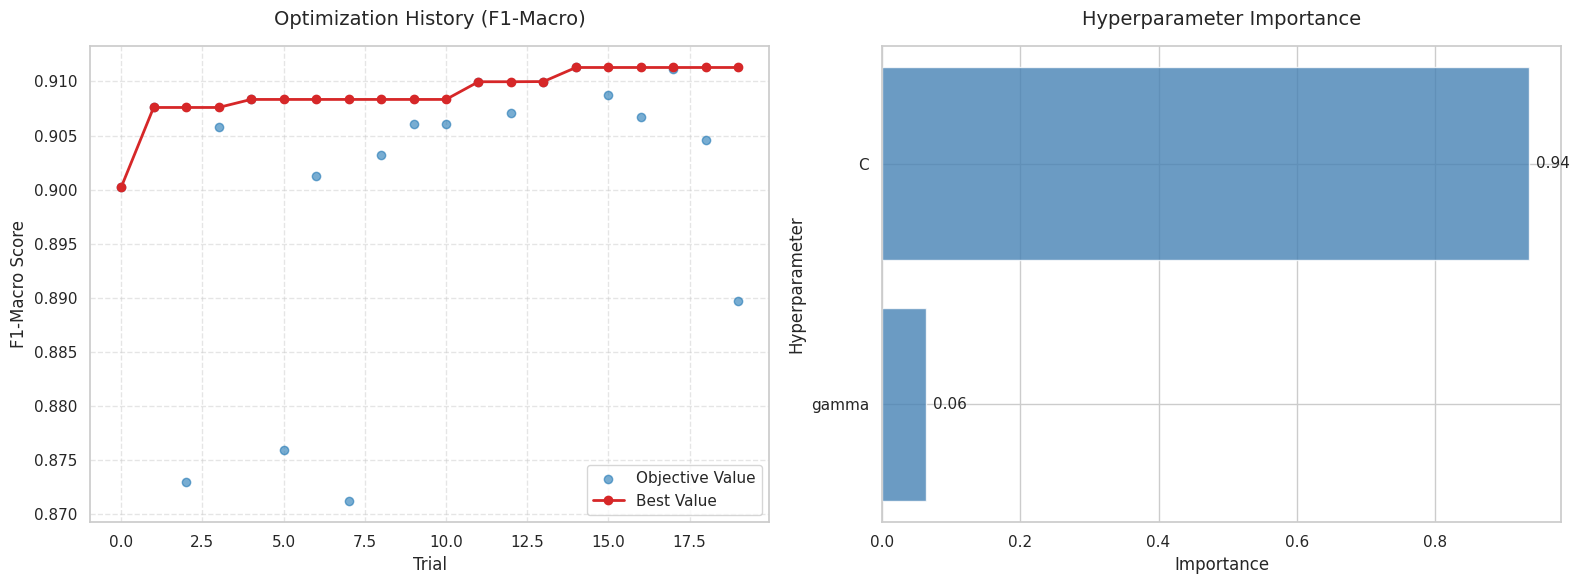


Best parameters successfully saved for the 5-Seed Stability Check!


In [33]:
print("--- PLOTTING CUSTOM OPTIMIZATION RESULTS (1x2 LAYOUT) ---")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# PLOT 1: OPTIMIZATION HISTORY 
# ==========================================
trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_numbers = [t.number for t in trials]
trial_values = [t.value for t in trials]
best_values = np.maximum.accumulate(trial_values)

ax1.scatter(trial_numbers, trial_values, color='#1f77b4', alpha=0.6, label='Objective Value')
ax1.plot(trial_numbers, best_values, color='#d62728', marker='o', linewidth=2, label='Best Value')
ax1.set_title("Optimization History (F1-Macro)", fontsize=14, pad=15)
ax1.set_xlabel("Trial")
ax1.set_ylabel("F1-Macro Score")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# ==========================================
# PLOT 2: HYPERPARAMETER IMPORTANCE 
# ==========================================
# IMPORTANT STEP: Lock the seeds for the fANOVA algorithm so that the data never jumps.
evaluator = FanovaImportanceEvaluator(seed=RANDOM_SEED)

importances = optuna.importance.get_param_importances(study, evaluator=evaluator)

params = list(importances.keys())[::-1]
vals = list(importances.values())[::-1]

bars = ax2.barh(params, vals, color='steelblue', alpha=0.8)
ax2.set_title("Hyperparameter Importance", fontsize=14, pad=15)
ax2.set_xlabel("Importance")
ax2.set_ylabel("Hyperparameter")

for bar in bars:
    ax2.text(bar.get_width() + 0.01, 
             bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.2f}', 
             va='center', ha='left', fontsize=11)

plt.tight_layout()
plt.show()

# Save the best parameters for Step 5
best_svm_params = study.best_params
print("\nBest parameters successfully saved for the 5-Seed Stability Check!")

## 5. Statistical Stability & Final Evaluation

In this final stage, we conduct a rigorous evaluation of our SVM model across three main parts:
1. **Statistical Stability Check**: Assessing the robustness of the optimal hyperparameters on the Validation set across 5 different random seeds.
2. **Final Unbiased Report**: Performing a single, definitive evaluation on the 10,000-sample hold-out Test set.
3. **Advanced Analysis**: Exploring computational efficiency (Quantitative) and model error patterns (Qualitative).

### 5.1 Statistical Stability Check

To ensure our results are not due to chance, we re-evaluate the model using the best parameters found by Optuna. We use 5 specific seeds for data splitting and PCA initialization: `{42, 5435, 123, 2026, 23}`.

We report the Mean ($\mu$) and Standard Deviation ($\sigma$) for Accuracy, Precision, Recall, Macro-F1, and Training Time.

In [34]:
print("--- 5.1 STABILITY CHECK ON VALIDATION SET ---")
print(f"{'Seed':<7} | {'Acc':<8} | {'Prec':<8} | {'Rec':<8} | {'F1':<8} | {'Time':<8}")
print("-" * 65)

# Define the 5 specific seeds required by the rubric
seeds = SEEDS

# Dictionary to store performance for statistical reporting
val_metrics = {
    'Accuracy': [], 'Precision': [], 'Recall': [], 'Macro-F1': [], 'Train_Time': []
}

for seed in seeds:
    # 1. Re-split data using the current seed
    X_tr, X_v, y_tr, y_v = train_test_split(
        X_raw, y_raw, 
        test_size=0.1, 
        random_state=seed, 
        stratify=y_raw
    )
    
    # 2. Apply Preprocessing
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_v_sc = sc.transform(X_v)
    
    pca_inner = PCA(n_components=0.95, random_state=seed)
    X_tr_pca_inner = pca_inner.fit_transform(X_tr_sc)
    X_v_pca_inner = pca_inner.transform(X_v_sc)
    
    # 3. Optimize for GPU (float32 conversion)
    X_tr_gpu = np.array(X_tr_pca_inner, dtype=np.float32)
    X_v_gpu = np.array(X_v_pca_inner, dtype=np.float32)
    y_tr_gpu = np.array(y_tr, dtype=np.float32)
    
    # 4. Initialize and Train Model using best parameters from Optuna
    model_inner = SVC(
        kernel='rbf', 
        C=best_svm_params['C'], 
        gamma=best_svm_params['gamma'], 
        cache_size=3000
    )
    
    start_fit = time.time()
    model_inner.fit(X_tr_gpu, y_tr_gpu)
    elapsed_fit = time.time() - start_fit
    
    # 5. Predict on the Validation Set
    preds_v = model_inner.predict(X_v_gpu)
    if hasattr(preds_v, 'get'): preds_v = preds_v.get()
    
    # 6. Calculate all metrics
    acc = accuracy_score(y_v, preds_v)
    prec = precision_score(y_v, preds_v, average='macro')
    rec = recall_score(y_v, preds_v, average='macro')
    f1 = f1_score(y_v, preds_v, average='macro')
    
    # 7. Store metrics
    val_metrics['Accuracy'].append(acc)
    val_metrics['Precision'].append(prec)
    val_metrics['Recall'].append(rec)
    val_metrics['Macro-F1'].append(f1)
    val_metrics['Train_Time'].append(elapsed_fit)
    
    # Show all metrics for the current seed
    print(f"{seed:<7} | {acc:<8.4f} | {prec:<8.4f} | {rec:<8.4f} | {f1:<8.4f} | {elapsed_fit:.2f}s")

# --- FINAL RELIABILITY REPORT ---
print("\n" + "="*65)
print("RELIABILITY METRICS: Mean (μ) ± Standard Deviation (σ)")
print("-" * 65)
for metric, values in val_metrics.items():
    mu = np.mean(values)
    sigma = np.std(values)
    unit = "s" if metric == 'Train_Time' else ""
    print(f" {metric:<12}: {mu:>8.4f}{unit} ± {sigma:<6.6f}{unit}")
print("="*65)

--- 5.1 STABILITY CHECK ON VALIDATION SET ---
Seed    | Acc      | Prec     | Rec      | F1       | Time    
-----------------------------------------------------------------
42      | 0.9115   | 0.9112   | 0.9115   | 0.9113   | 3.89s
5435    | 0.9062   | 0.9055   | 0.9062   | 0.9056   | 3.88s
123     | 0.9052   | 0.9054   | 0.9052   | 0.9051   | 3.84s
2026    | 0.9025   | 0.9020   | 0.9025   | 0.9022   | 3.87s
23      | 0.8960   | 0.8958   | 0.8960   | 0.8958   | 3.88s

RELIABILITY METRICS: Mean (μ) ± Standard Deviation (σ)
-----------------------------------------------------------------
 Accuracy    :   0.9043 ± 0.005064
 Precision   :   0.9040 ± 0.005033
 Recall      :   0.9043 ± 0.005064
 Macro-F1    :   0.9040 ± 0.005039
 Train_Time  :   3.8691s ± 0.017280s


### 5.2 Final Unbiased Report
In this phase, we perform a single, definitive evaluation on the **10,000-sample hold-out Test Set**. To ensure an unbiased report, we use the model only once on this data to reflect its true generalization capability.

In [35]:
print("--- 5.2 FINAL UNBIASED TEST SET EVALUATION (TRAINED ON FULL 60K) ---")

# =======================================================
# STEP 1: REPROCESS ALL 60,000 SAMPLES (X_raw)
# =======================================================
final_scaler = StandardScaler()
final_pca = PCA(n_components=0.95, random_state=RANDOM_SEED)

X_raw_scaled = final_scaler.fit_transform(X_raw)
X_raw_pca = final_pca.fit_transform(X_raw_scaled)

X_test_scaled_final = final_scaler.transform(X_test_final)
X_test_pca_final = final_pca.transform(X_test_scaled_final)

X_train_60k_gpu = np.array(X_raw_pca, dtype=np.float32)
y_train_60k_gpu = np.array(y_raw, dtype=np.float32)  
X_test_10k_gpu = np.array(X_test_pca_final, dtype=np.float32)

# =======================================================
# STEP 2: CREATE AND TRAIN A MODEL OVER 60K
# =======================================================
svm_model_60k = SVC(
    kernel='rbf', 
    C=best_svm_params['C'], 
    gamma=best_svm_params['gamma'], 
    cache_size=3000
)

# Time and Fit Model
start_train = time.time()
svm_model_60k.fit(X_train_60k_gpu, y_train_60k_gpu)
train_time_60k = time.time() - start_train

# =======================================================
# STEP 3: PREDICTION AND EVALUATION BASED ON 10K TEST
# =======================================================
final_test_preds = svm_model_60k.predict(X_test_10k_gpu)

if hasattr(final_test_preds, 'get'):
    final_test_preds = final_test_preds.get()

# Calculate Metrics
test_acc = accuracy_score(y_test_final, final_test_preds)
test_prec = precision_score(y_test_final, final_test_preds, average='macro', zero_division=0)
test_rec = recall_score(y_test_final, final_test_preds, average='macro')
test_f1 = f1_score(y_test_final, final_test_preds, average='macro')

print("\n" + "="*50)
print(f"{'FINAL TEST METRIC (60k Train)':<30} | {'SCORE':<15}")
print("-" * 50)
print(f"{'Accuracy':<30} | {test_acc:<15.4f}")
print(f"{'Precision (Macro)':<30} | {test_prec:<15.4f}")
print(f"{'Recall (Macro)':<30} | {test_rec:<15.4f}")
print(f"{'F1-Score (Macro)':<30} | {test_f1:<15.4f}")
print("-" * 50)
print(f"{'Training Time (60k)':<30} | {train_time_60k:<10.4f} sec")
print("="*50)

--- 5.2 FINAL UNBIASED TEST SET EVALUATION (TRAINED ON FULL 60K) ---

FINAL TEST METRIC (60k Train)  | SCORE          
--------------------------------------------------
Accuracy                       | 0.9000         
Precision (Macro)              | 0.8999         
Recall (Macro)                 | 0.9000         
F1-Score (Macro)               | 0.8999         
--------------------------------------------------
Training Time (60k)            | 4.1778     sec


### 5.3 Quantitative Analysis & Efficiency

This phase focuses on the rigorous numerical evaluation of the model's performance and computational cost. 
1. **Master Comparison Table**: We report the Mean ($\mu$) and Standard Deviation ($\sigma$) for all primary metrics obtained from the 5-seed validation stability check.
2. **Efficiency Benchmarking**: We calculate the inference latency per image (ms) to evaluate the model's suitability for real-time applications.
3. **Hyperparameter Justification**: We visualize the Optuna optimization process to justify the selection of our final hyperparameter configuration ($C$ and $\gamma$).

--- MASTER COMPARISON TABLE (5-SEED VALIDATION) ---

METRIC             | MEAN (μ)        | STD (σ)        
-------------------------------------------------------
Accuracy           |   0.9043       | 0.005064      
Precision          |   0.9040       | 0.005033      
Recall             |   0.9043       | 0.005064      
Macro-F1           |   0.9040       | 0.005039      
Train_Time         |   3.8691s      | 0.017280s     

Efficiency Metric (Latency): 0.0697 ms/image
Number of Support Vectors:    40399

--- OPTIMIZATION VISUALS ---



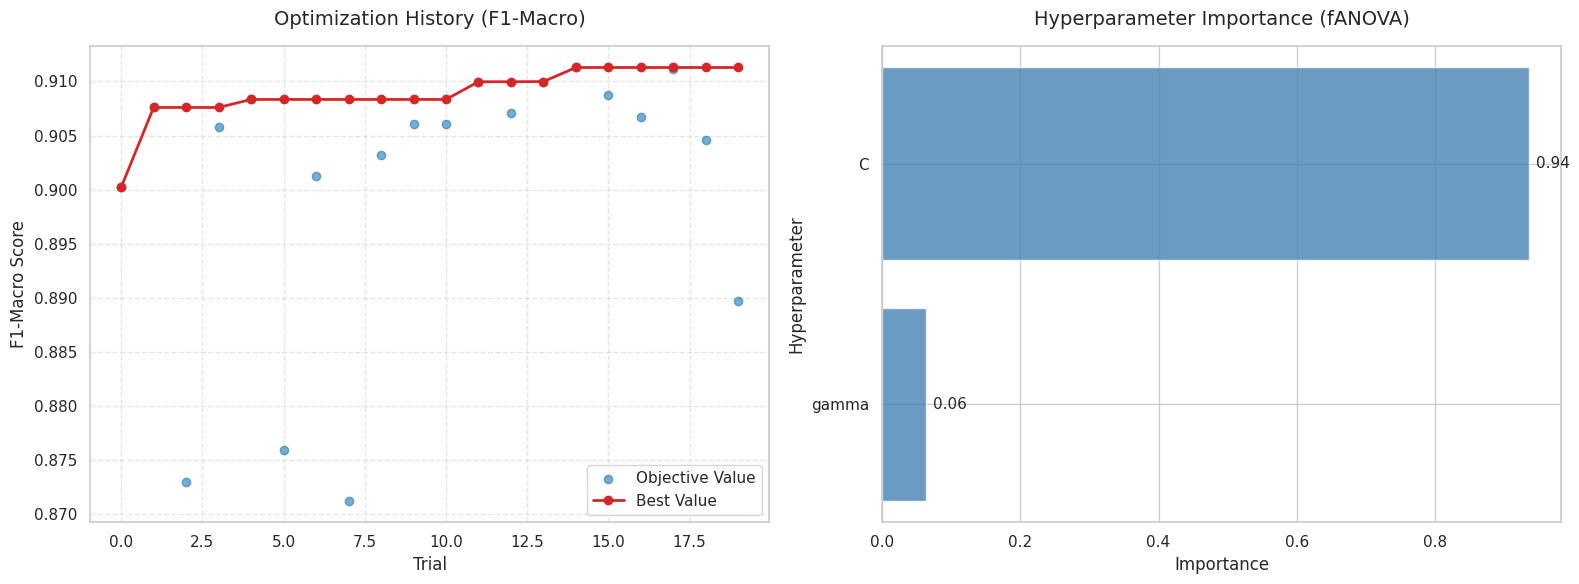


Best hyperparameters justified: {'C': 17.13889027352405, 'gamma': 'scale'}


In [36]:
print("--- MASTER COMPARISON TABLE (5-SEED VALIDATION) ---")

# 1. Print Master Table using Owen's preferred formatting
print("\n" + "="*55)
print(f"{'METRIC':<18} | {'MEAN (μ)':<15} | {'STD (σ)':<15}")
print("-" * 55)

metric_names = ['Accuracy', 'Precision', 'Recall', 'Macro-F1', 'Train_Time']

for m in metric_names:
    mu = np.mean(val_metrics[m])
    sigma = np.std(val_metrics[m])
    
    # Add 's' unit for training time
    unit = "s" if m == 'Train_Time' else ""
    
    # Format the mean and std into the template
    print(f"{m:<18} | {mu:>8.4f}{unit:<6} | {sigma:>8.6f}{unit:<6}")

print("="*55)

# 2. Efficiency Benchmark (Latency & Support Vectors)
X_test_gpu = np.array(X_test_pca, dtype=np.float32)

# Measure Latency
start_lat = time.time()
_ = svm_model_60k.predict(X_test_gpu)
avg_latency_ms = ((time.time() - start_lat) / len(y_test_final)) * 1000

total_sv = len(svm_model_60k.support_)

print(f"\nEfficiency Metric (Latency): {avg_latency_ms:.4f} ms/image")
print(f"Number of Support Vectors:    {total_sv}")

print("\n--- OPTIMIZATION VISUALS ---\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: OPTIMIZATION HISTORY ---
trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_numbers = [t.number for t in trials]
trial_values = [t.value for t in trials]
best_values = np.maximum.accumulate(trial_values)

ax1.scatter(trial_numbers, trial_values, color='#1f77b4', alpha=0.6, label='Objective Value')
ax1.plot(trial_numbers, best_values, color='#d62728', marker='o', linewidth=2, label='Best Value')
ax1.set_title("Optimization History (F1-Macro)", fontsize=14, pad=15)
ax1.set_xlabel("Trial"); ax1.set_ylabel("F1-Macro Score")
ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.5)

# --- PLOT 2: HYPERPARAMETER IMPORTANCE ---
# Using the same fANOVA logic as before
evaluator = FanovaImportanceEvaluator(seed=RANDOM_SEED)
importances = optuna.importance.get_param_importances(study, evaluator=evaluator)
params = list(importances.keys())[::-1]
vals = list(importances.values())[::-1]

bars = ax2.barh(params, vals, color='steelblue', alpha=0.8)
ax2.set_title("Hyperparameter Importance (fANOVA)", fontsize=14, pad=15)
ax2.set_xlabel("Importance"); ax2.set_ylabel("Hyperparameter")

for bar in bars:
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.2f}', va='center', ha='left', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nBest hyperparameters justified: {study.best_params}")

### 5.4. Qualitative Analysis & Interpretability

In this final phase, we transition from global metrics to a granular inspection of the model's behavior:
1. **Class-Wise F1-Score Heatmap**: Identifying which specific categories are the "weak links" in our classification pipeline.
2. **Error Grids (Success vs. Failure)**: Comparing 5 correctly classified samples against 5 misclassified ones.
3. **Top-3 Probability Distributions**: Analyzing the confidence of the model to distinguish between:
    * **High Ambiguity**: Model is unsure between two similar classes (e.g., Shirt vs. T-shirt).
    * **Overconfident Errors**: Model is highly confident but fundamentally wrong.

--- PER-CLASS PERFORMANCE ANALYSIS ---



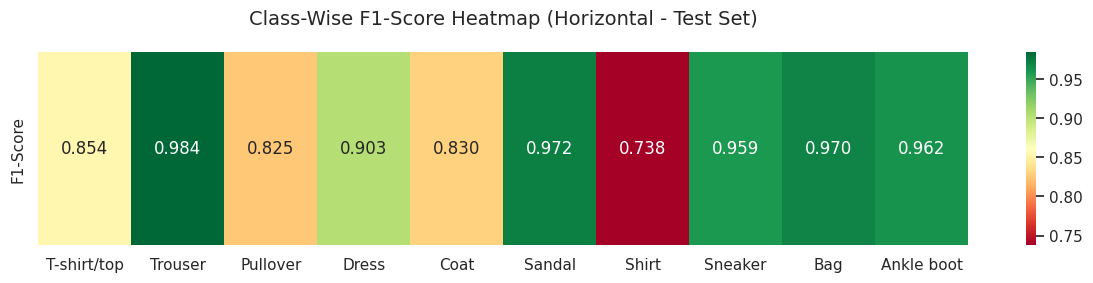

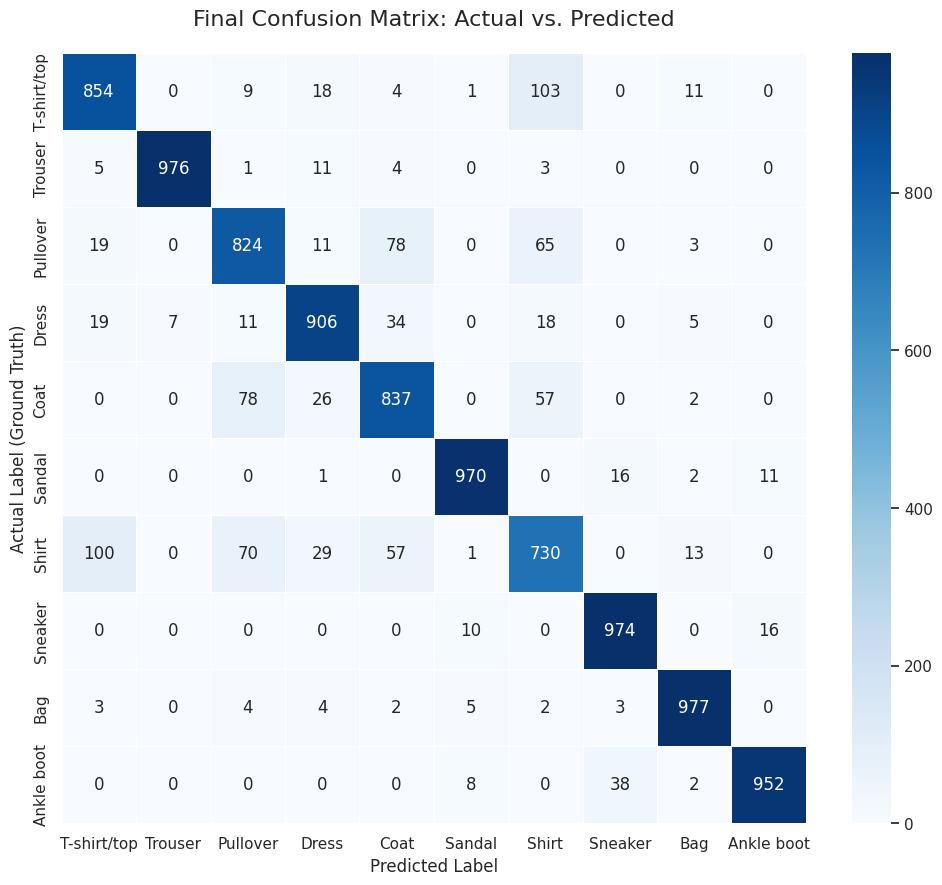

In [37]:
print("--- PER-CLASS PERFORMANCE ANALYSIS ---\n")

# 1. Class-Wise F1-Score Heatmap 
f1_per_class = f1_score(y_test_final, final_test_preds, average=None)

# Tạo DataFrame với 1 hàng và 10 cột
f1_df_horizontal = pd.DataFrame(f1_per_class.reshape(1, -1), 
                                 columns=class_names, 
                                 index=['F1-Score'])

plt.figure(figsize=(15, 2.5)) 
sns.heatmap(f1_df_horizontal, annot=True, cmap='RdYlGn', fmt='.3f', cbar=True)
plt.title("Class-Wise F1-Score Heatmap (Horizontal - Test Set)", fontsize=14, pad=20)
plt.show()

# 2. Confusion Matrix Heatmap 
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test_final, final_test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, linewidths=.5)
plt.title('Final Confusion Matrix: Actual vs. Predicted', fontsize=16, pad=20)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

--- ERROR GRIDS: SUCCESS VS. FAILURE ---



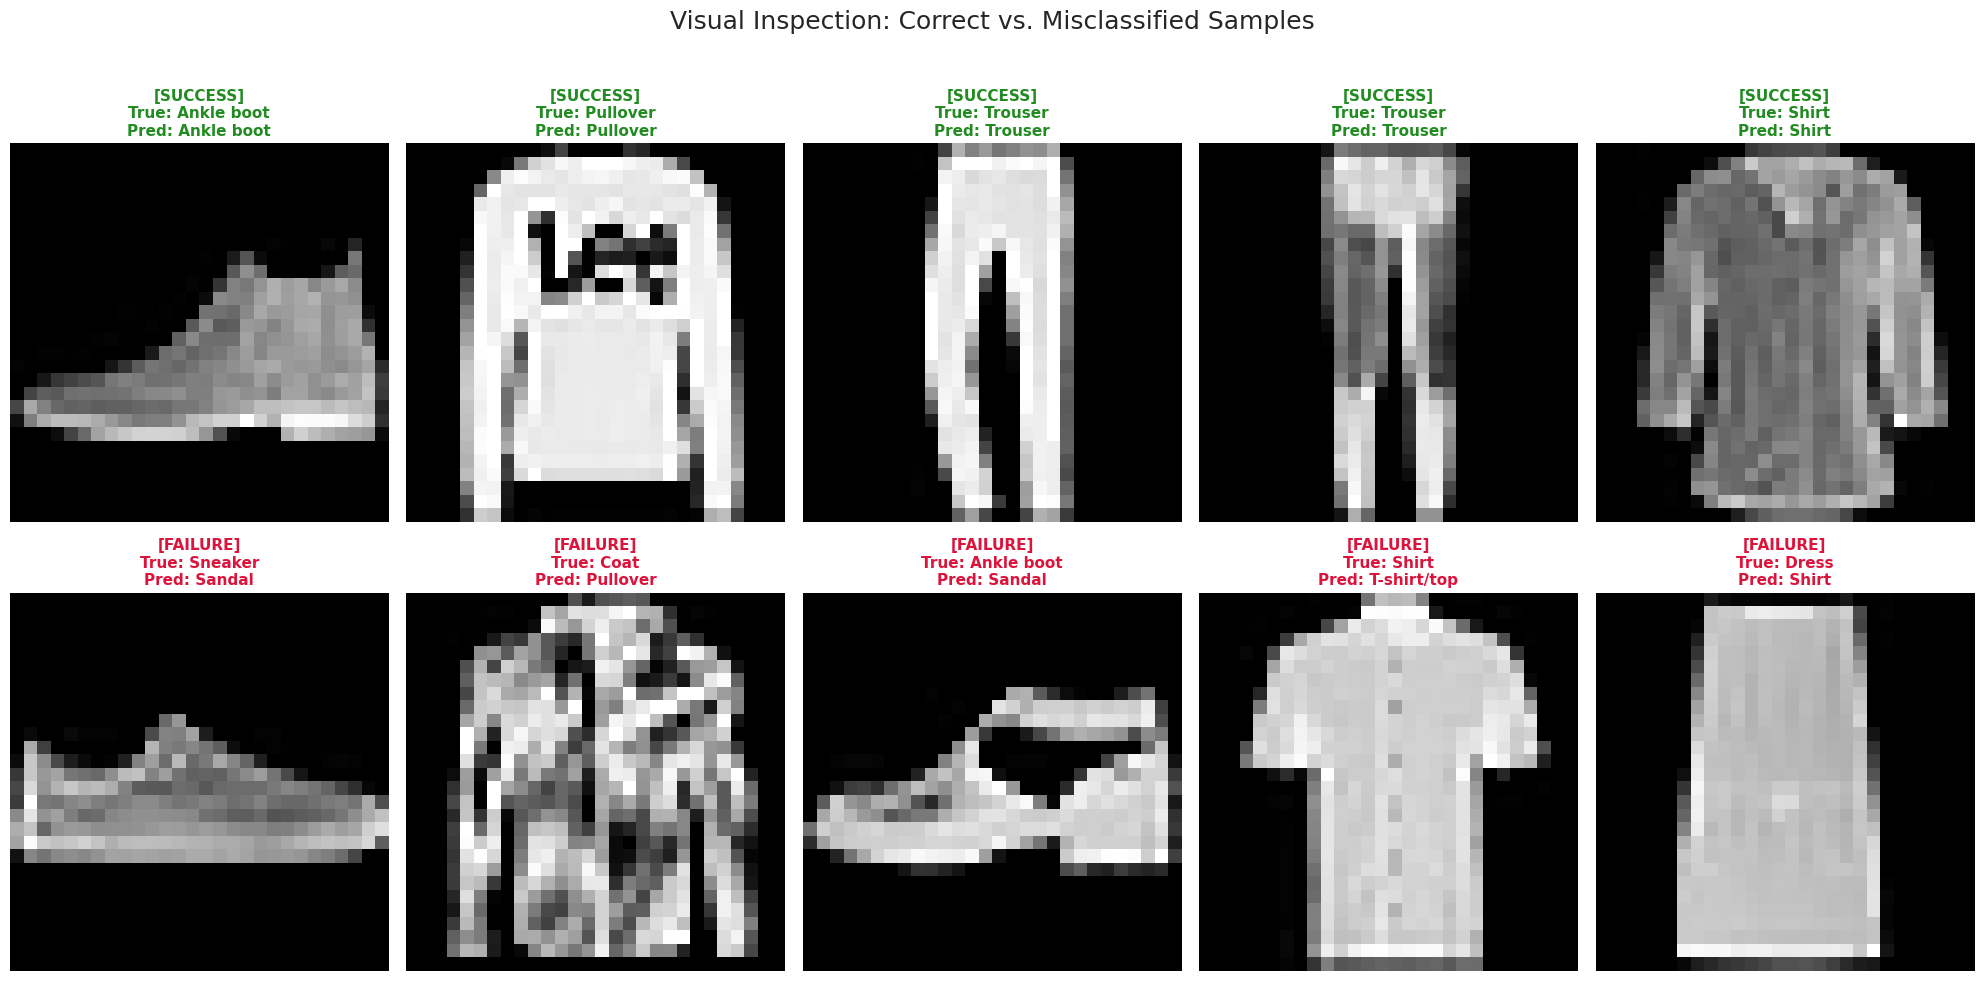

In [38]:
print("--- ERROR GRIDS: SUCCESS VS. FAILURE ---\n")

# Identify indices for correctly and incorrectly classified samples
success_idx = np.where(final_test_preds == y_test_final)[0][:5]
failure_idx = np.where(final_test_preds != y_test_final)[0][:5]
display_idx = np.concatenate([success_idx, failure_idx])

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, idx in enumerate(display_idx):
    ax = axes[i]
    # Use the original raw test data for display
    ax.imshow(X_test_final[idx].reshape(28, 28), cmap='gray')
    
    true_label = class_names[int(y_test_final[idx])]
    pred_label = class_names[int(final_test_preds[idx])]
    
    # SUCCESS (top row) vs FAILURE (bottom row)
    is_success = i < 5
    title_color = 'forestgreen' if is_success else 'crimson'
    status = "SUCCESS" if is_success else "FAILURE"
    
    ax.set_title(f"[{status}]\nTrue: {true_label}\nPred: {pred_label}", 
                 color=title_color, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle("Visual Inspection: Correct vs. Misclassified Samples", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## 6. Ablation Study

To scientifically validate the contribution of each component in our proposed pipeline, we conduct an **Ablation Study**. By systematically removing key preprocessing and optimization steps, we can quantify their direct impact on the model's Macro-F1 score and inference time.

**Ablation Configurations:**
1. **Raw Baseline:** SVM on raw pixel values (No Scaler, No PCA, Default Params).
2. **No PCA:** Scaled features using all 784 dimensions (StandardScaler + Default SVM).
3. **No Tuning:** Full preprocessing but with default SVM hyperparameters ($C=1.0$, $\gamma=\text{'scale'}$).
4. **Proposed Model:** Our complete pipeline (StandardScaler + PCA 95% + Optuna Tuned SVM).

--- 6.1 EXECUTING ABLATION STUDY ---
[1. Raw Data + Default SVM] completed: F1 = 0.8808 | Time = 4.59s
[2. Scaled (No PCA) + Default SVM] completed: F1 = 0.8848 | Time = 4.60s
[3. Scaled + PCA + Default SVM] completed: F1 = 0.8822 | Time = 3.20s
[4. Proposed Pipeline] integrated from previous results.

--- 6.2 ABLATION STUDY DETAILED METRICS ---

Configuration                       | Accuracy   | Precision  | Recall     | Macro-F1   | Time (s)
-----------------------------------------------------------------------------------------------
1. Raw Data + Default SVM           | 0.8813     | 0.8807     | 0.8813     | 0.8808     | 4.59    
2. Scaled (No PCA) + Default SVM    | 0.8854     | 0.8848     | 0.8854     | 0.8848     | 4.60    
3. Scaled + PCA + Default SVM       | 0.8827     | 0.8822     | 0.8827     | 0.8822     | 3.20    
4. Proposed Pipeline                | 0.9000     | 0.8999     | 0.9000     | 0.8999     | 4.18    

--- 6.3 ABLATION STUDY VISUALIZATION ---



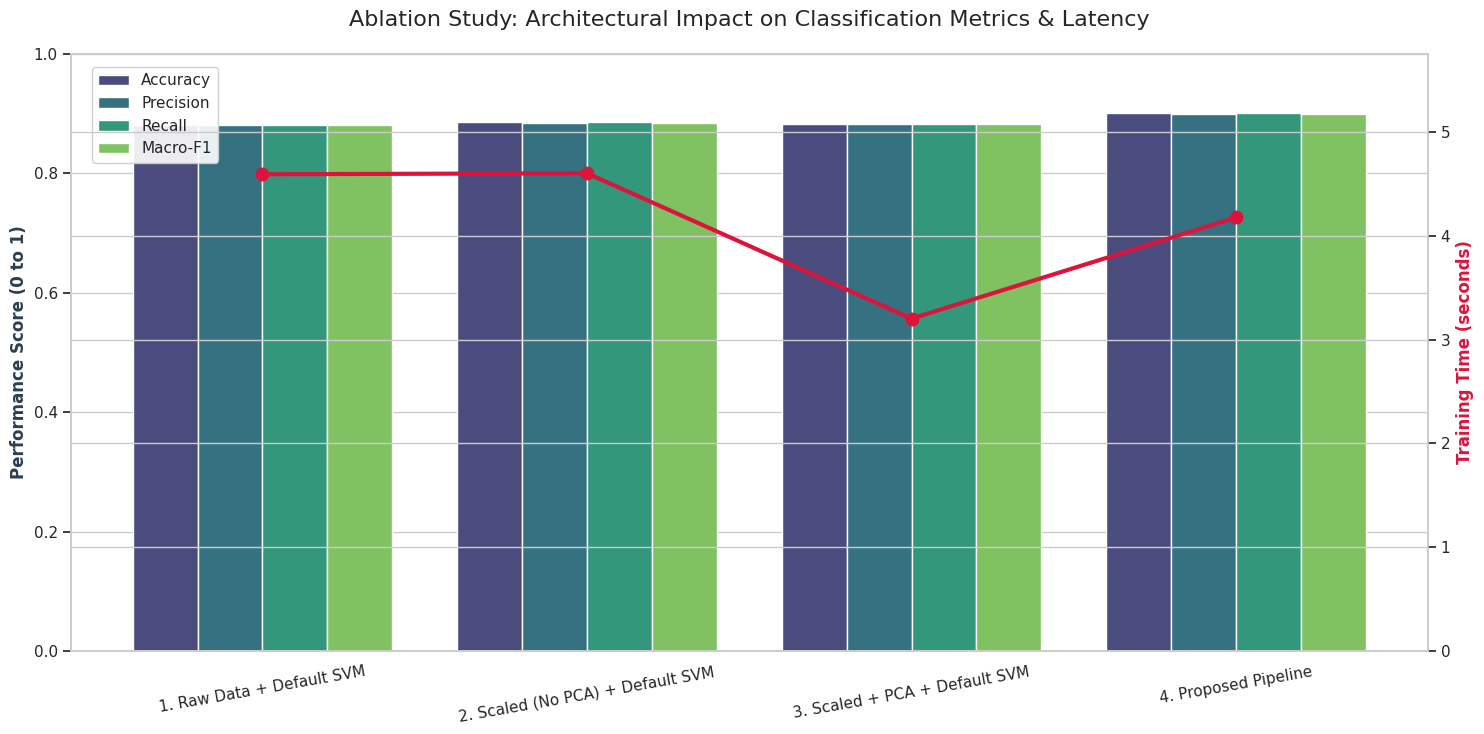

In [39]:
# ==============================================================================
# 6. ABLATION STUDY: COMPONENT IMPACT ANALYSIS
# ==============================================================================
print("--- 6.1 EXECUTING ABLATION STUDY ---")

# 1. Raw Data
X_train_raw = np.array(X_train, dtype=np.float32)
X_test_raw = np.array(X_test_final, dtype=np.float32)
y_train_gpu = np.array(y_train, dtype=np.float32) 

# 2. Scale Data (No PCA)
X_train_scaled_gpu = np.array(scaler.transform(X_train), dtype=np.float32)
X_test_scaled_gpu = np.array(scaler.transform(X_test_final), dtype=np.float32)

# 3. Scale + PCA 
X_train_pca_gpu = np.array(X_train_pca, dtype=np.float32)
X_test_pca_gpu = np.array(X_test_pca, dtype=np.float32)

ablation_results = []

def run_ablation(name, X_tr, y_tr, X_te, y_te, model_config):
    """Hàm chuẩn hóa việc huấn luyện và đo lường (Phiên bản Clean Code)"""
    start = time.time()
    
    # Sử dụng tham số y_tr truyền vào thay vì biến global
    model_config.fit(X_tr, y_tr)
    train_time = time.time() - start
    
    preds = model_config.predict(X_te)
    if hasattr(preds, 'get'): 
        preds = preds.get()
    
    # Sử dụng tham số y_te truyền vào
    acc = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, average='macro', zero_division=0)
    rec = recall_score(y_te, preds, average='macro')
    f1 = f1_score(y_te, preds, average='macro')
    
    ablation_results.append({
        'Configuration': name, 
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'Macro-F1': f1, 
        'Train_Time (s)': train_time
    })
    print(f"[{name}] completed: F1 = {f1:.4f} | Time = {train_time:.2f}s")


# 1. Config 1: Raw Baseline
run_ablation("1. Raw Data + Default SVM", 
             X_train_raw, y_train_gpu, 
             X_test_raw, y_test_final, 
             SVC(kernel='rbf', cache_size=3000))

# 2. Config 2: Scaled (No PCA)
run_ablation("2. Scaled (No PCA) + Default SVM", 
             X_train_scaled_gpu, y_train_gpu, 
             X_test_scaled_gpu, y_test_final, 
             SVC(kernel='rbf', cache_size=3000))

# 3. Config 3: PCA Data
run_ablation("3. Scaled + PCA + Default SVM", 
             X_train_pca_gpu, y_train_gpu, 
             X_test_pca_gpu, y_test_final, 
             SVC(kernel='rbf', cache_size=3000))

# Config 4: Pipeline 
ablation_results.append({
    'Configuration': '4. Proposed Pipeline', 
    'Accuracy': test_acc,
    'Precision': test_prec,
    'Recall': test_rec,
    'Macro-F1': test_f1, 
    'Train_Time (s)': train_time_60k
})
print(f"[4. Proposed Pipeline] integrated from previous results.")


print("\n--- 6.2 ABLATION STUDY DETAILED METRICS ---")
df_ablation = pd.DataFrame(ablation_results)

print("\n" + "="*95)
print(f"{'Configuration':<35} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'Macro-F1':<10} | {'Time (s)':<8}")
print("-" * 95)
for _, row in df_ablation.iterrows():
    print(f"{row['Configuration']:<35} | {row['Accuracy']:<10.4f} | {row['Precision']:<10.4f} | {row['Recall']:<10.4f} | {row['Macro-F1']:<10.4f} | {row['Train_Time (s)']:<8.2f}")
print("="*95)

print("\n--- 6.3 ABLATION STUDY VISUALIZATION ---\n")
df_melted = df_ablation.melt(id_vars=['Configuration', 'Train_Time (s)'], 
                             value_vars=['Accuracy', 'Precision', 'Recall', 'Macro-F1'],
                             var_name='Metric', value_name='Score')

fig, ax1 = plt.subplots(figsize=(15, 7.5))

# Vẽ cột Metrics
sns.barplot(x='Configuration', y='Score', hue='Metric', data=df_melted, palette='viridis', ax=ax1)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel('Performance Score (0 to 1)', fontsize=12, fontweight='bold', color='#2c3e50')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=10, labelsize=11)
ax1.legend(loc='upper left', bbox_to_anchor=(0.01, 0.99), framealpha=0.9)

# Vẽ đường Train Time
ax2 = ax1.twinx()
ax2.plot(df_ablation['Configuration'], df_ablation['Train_Time (s)'], color='crimson', marker='o', linewidth=3, markersize=9)
ax2.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold', color='crimson')
ax2.set_ylim(0, df_ablation['Train_Time (s)'].max() * 1.25)


plt.title("Ablation Study: Architectural Impact on Classification Metrics & Latency", fontsize=16, pad=20)
plt.tight_layout()
plt.show()